In [412]:
import win32com.client as com
import os
import pandas as pd
import geopandas as gpd
import numpy as np
from functools import lru_cache
from collections import defaultdict
from shapely import wkt
import osmnx as ox
import ast
import matplotlib.pyplot as plt


## __Open Visum Net__

In [378]:
#Open network .ver file (from local disk not onedrive)
import win32com.client

#Visum = com.Dispatch("Visum.Visum.250") #Add .250 for Visum 25 version
Visum = com.Dispatch("Visum.Visum") #Visum 24 version
Visum.LoadVersion(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Projects\RedOSMNX_AMG_24.ver')
C = win32com.client.constants

In [379]:
Net = Visum.Net

## __Nodes & Links__

In [380]:
# Nodos
nodes = Visum.Net.Nodes
node_ids = nodes.GetMultiAttValues("No")  # ID node en Visum
node_x = nodes.GetMultiAttValues("XCoord")
node_y = nodes.GetMultiAttValues("YCoord")
geom_nodes = nodes.GetMultiAttValues("WKTLoc")
#node_osmid = nodes.GetMultiAttValues("OSMID") # ID original


# Links
links = Visum.Net.Links
link_ids = links.GetMultiAttValues("No")  # ID del enlace
from_node = links.GetMultiAttValues("FromNodeNo")
to_node = links.GetMultiAttValues("ToNodeNo")
lenght_km = links.GetMultiAttValues("Length")
length_m = links.GetMultiAttValues("LENGTH_M")
type_no = links.GetMultiAttValues("TypeNo")
highway_type = links.GetMultiAttValues("HIGHWAY_NO")
key = links.GetMultiAttValues("KEY") # Clave del enlace
geom_links = links.GetMultiAttValues("WKTPoly")
#link_osmid = links.GetMultiAttValues("OSMID") # ID original
#u = links.GetMultiAttValues("U") # Nodo origen
#v = links.GetMultiAttValues("V") # Nodo destino



In [381]:
# Nodos DataFrame
df_nodes = pd.DataFrame({
    "NodeNo": [n[1] for n in node_ids],
    "y": [y[1] for y in node_y],
    "x": [x[1] for x in node_x],
    "geometry": [gn[1] for gn in geom_nodes]
})

# Links DataFrame
df_links = pd.DataFrame({
    "LinkNo": [l[1] for l in link_ids],
    "FromNode": [fn[1] for fn in from_node],
    "ToNode": [tn[1] for tn in to_node],
    "Length_m": [lm[1] for lm in length_m],
    "TypeNo": [tn[1] for tn in type_no],
    "Length_km": [le[1] for le in lenght_km],
    "HighwayType": [ht[1] for ht in highway_type],
    "geometry": [gl[1] for gl in geom_links]
})

In [382]:
def parse_highway(hwy):
    if isinstance(hwy, list):
        return hwy
    if not isinstance(hwy, str):
        return []
    hwy = hwy.strip()
    if hwy == "" or hwy == "[]":
        return []
    if hwy.startswith("[") and hwy.endswith("]"):
        try:
            return ast.literal_eval(hwy)
        except (ValueError, SyntaxError):
            return []
    return [hwy]

# ejemplo
print(parse_highway("service"))                 # ['service']
print(parse_highway("['service']"))             # ['service']
print(parse_highway("['footway', 'steps']"))    # ['footway', 'steps']

['service']
['service']
['footway', 'steps']


In [290]:
df_links[df_links['LinkNo'] == 312617]

,LinkNo,FromNode,ToNode,Length_m,TypeNo,Length_km,HighwayType,geometry
359916,312617.0,128199.0,128200.0,57.558894,1.0,0.057771,['service'],"LINESTRING(-103.4338 20.6252,-103.4337 20.6249..."
359917,312617.0,128200.0,128199.0,57.558894,1.0,0.057771,['service'],"LINESTRING(-103.4336 20.6247,-103.4337 20.6249..."


In [383]:
df_nodes.set_index("NodeNo", inplace=True)
df_links.set_index(["FromNode", "ToNode", "LinkNo"], inplace=True)

In [443]:
# Estos datos estan originalmente en ESPG:4326 (Visum lon/lat)
gdf_nodes = gpd.GeoDataFrame(
    df_nodes, 
    geometry=df_nodes["geometry"].apply(wkt.loads),
    crs="EPSG:4326")
gdf_links = gpd.GeoDataFrame(
    df_links, 
    geometry=df_links["geometry"].apply(wkt.loads),
    crs="EPSG:4326")

# Transformar a metros(EPSG:32613)
gdf_nodes = gdf_nodes.to_crs("EPSG:32613")
gdf_links = gdf_links.to_crs("EPSG:32613")

gdf_nodes['x'] = gdf_nodes.geometry.x
gdf_nodes['y'] = gdf_nodes.geometry.y

In [444]:
print("nodes unique:", df_nodes.index.is_unique)
print("edges unique:", df_links.index.is_unique)

print("dup nodes:", df_nodes.index[df_nodes.index.duplicated()])
print("dup edges:", df_links.index[df_links.index.duplicated()])

nodes unique: True
edges unique: True
dup nodes: Index([], dtype='float64', name='NodeNo')
dup edges: MultiIndex([], names=['FromNode', 'ToNode', 'LinkNo'])


## __Reconstruir grafo__

In [445]:
G_visum = ox.graph_from_gdfs(gdf_nodes, gdf_links)

In [446]:
nodes_from_visum, edges_from_visum = ox.graph_to_gdfs(G_visum, nodes=True, edges=True)
nodes_from_visum = nodes_from_visum.reset_index()
edges_from_visum = edges_from_visum.reset_index()
print('nodos en el grafo tal cual de visum:', len(nodes_from_visum))
print('enlaces en el grafo tal cual de visum:', len(edges_from_visum))
nodes_from_visum.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Objects\Nodes\nodes_from_visum.shp')
edges_from_visum.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Objects\Links\edges_from_visum.shp')

nodos en el grafo tal cual de visum: 213456
enlaces en el grafo tal cual de visum: 593968


C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_19160\1795005028.py:7: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  edges_from_visum.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Objects\Links\edges_from_visum.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'HighwayType' to 'HighwayTyp'
  ogr_write(


### Remove artificial link objects (companeros que creo Visum)
- __links no transitables__

In [447]:
#Remove artificial links (TypeNo == 0)
edges_to_remove = [
    (u, v, k)
    for u, v, k, d in G_visum.edges(keys=True, data=True)
    if d.get("Length_km") == 0.0 #Try this, a las inversas de los links importados, parece que les puso Length 0 (te descarta extra links para evitar malos snaps)
]

print(f"Enlaces a eliminar por tener Length 0: {len(edges_to_remove)}")

G_visum.remove_edges_from(edges_to_remove)

Enlaces a eliminar por tener Length 0: 93042


In [448]:
nodes_grafo, edges_grafo = ox.graph_to_gdfs(G_visum, nodes=True, edges=True)
print('nodos en el grafo tal cual de visum:', len(nodes_grafo))
print('enlaces donde hay circulacion de visum:', len(edges_grafo))

nodos en el grafo tal cual de visum: 213456
enlaces donde hay circulacion de visum: 500926


### Grafos for snapping bus stops

In [449]:
G_snap = G_visum.copy()
G_snap_service = G_visum.copy()
G_snap_livingST = G_visum.copy()

In [451]:
valid_highways = {
    'motorway',
    'motorway_link',
    'trunk',
    'trunk_link',
    'primary',
    'primary_link',
    'secondary',
    'secondary_link',
    'tertiary',
    'tertiary_link',
    'residential',
    'unclassified',
    #'service',
}

#if it has one of these, remove
unvalid_walkable_highways = {
    'footway',
    'pedestrian',
    'path',
    'steps',
    'busway'
}

service_living_street_highways = {
    'service',
    'living_street'
}

In [452]:
# links a eliminar
remove_walking_service = []
remove_non_service = []
remove_non_living_street = []

# Recorrer todos los links
for u, v, k, data in G_visum.edges(keys=True, data=True):

    hwy = parse_highway(data.get("HighwayType"))

    # Caso highway es lista
    if isinstance(hwy, list):
        if not any(h == 'service' for h in hwy):
            remove_non_service.append((u, v, k))
        if not any(h == 'living_street' for h in hwy):
            remove_non_living_street.append((u, v, k))
        # Si contiene algún tipo no válido, eliminar
        if any(h in unvalid_walkable_highways for h in hwy):
            remove_walking_service.append((u, v, k))
        # Si no contiene ninguno válido, eliminar
        if not any(h in valid_highways for h in hwy):
            remove_walking_service.append((u, v, k))

   
    # Si no tiene atributo highway
    else:
       remove_walking_service.append((u, v, k))


In [453]:
# Ver los edges que se van a borrar
removed_edges = ox.graph_to_gdfs(
    G_visum.edge_subgraph(remove_non_living_street),
    nodes=False
)
print(f"Edges a eliminar: {len(removed_edges)}")

counts = removed_edges["HighwayType"].value_counts()
for i, v in counts.items():
    print(i, v)

Edges a eliminar: 450723
['residential'] 269597
['service'] 73314
['tertiary'] 27874
['footway'] 21168
['unclassified'] 14134
['secondary'] 10094
['primary'] 7616
['path'] 6160
['cycleway'] 4195
['track'] 3148
['pedestrian'] 2756
[] 2436
['trunk'] 1414
['primary_link'] 780
['tertiary_link'] 735
['trunk_link'] 555
['steps'] 510
['secondary_link'] 510
['motorway_link'] 493
['footway', 'steps'] 493
['path', 'residential'] 428
['footway', 'residential'] 407
['motorway'] 373
['busway'] 289
['pedestrian', 'residential'] 207
['corridor'] 150
['track', 'residential'] 137
['steps', 'residential'] 82
['service', 'residential'] 75
['steps', 'corridor'] 52
['track', 'service'] 50
['service', 'path'] 49
['footway', 'service'] 48
['tertiary', 'residential'] 38
['track', 'unclassified'] 38
['footway', 'pedestrian'] 38
['pedestrian', 'steps'] 32
['track', 'path'] 30
['bridleway'] 30
['unclassified', 'residential'] 25
['footway', 'path'] 18
['footway', 'cycleway'] 17
['footway', 'steps', 'residential']

### Remove mode edges for 3 snap graphs

In [454]:
#Main graph remove non vial links (including service)
G_snap.remove_edges_from(remove_walking_service)
#Graph with only service links (everything else removed)
G_snap_service.remove_edges_from(remove_non_service)
#Graph with only living street links (everything else removed)
G_snap_livingST.remove_edges_from(remove_non_living_street)

### Verify CRS from graphs

In [456]:
# Reproyectar G_snap a EPSG: 4326 para que esté en la misma proyección que los puntos de parada
print("original G_snap CRS:", G_snap.graph['crs'])
print("original G_snap_service CRS:", G_snap_service.graph['crs'])
print("original G_snap_living_street CRS:", G_snap_livingST.graph['crs'])

original G_snap CRS: EPSG:32613
original G_snap_service CRS: EPSG:32613
original G_snap_living_street CRS: EPSG:32613


### Read original SP from IMEPLAN

In [538]:
bus_stops_imeplan = gpd.read_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Insumos IMEPLAN\Transporte Publico\amg_estategia_puntos_de_parada\AMG_estrategia_de_puntos_de_parada_de_transporte_publico_A04.shp')

### IMEPLAN stops were MULTIPOINT, __change to POINT__

In [539]:
# 1) Copia y revisa tipos geométricos
print(bus_stops_imeplan.geom_type.value_counts(dropna=False))

# 2) Convierte MultiPoint -> Point (una fila por punto)
bus_stops = bus_stops_imeplan.explode(index_parts=False).reset_index(drop=True)
print(bus_stops.geom_type.value_counts(dropna=False))

# 3) Quédate solo con Point válidos
bus_stops = bus_stops[bus_stops.geometry.notna() & (bus_stops.geom_type == "Point")].copy()
print(bus_stops.geom_type.value_counts(dropna=False))

# 4) Extrae coordenadas
bus_stops["XCoord"] = bus_stops.geometry.x
bus_stops["YCoord"] = bus_stops.geometry.y
print(bus_stops[["XCoord", "YCoord"]].head())

MultiPoint    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64
          XCoord        YCoord
0  680976.456130  2.272737e+06
1  681483.253691  2.280846e+06
2  700561.553323  2.281164e+06
3  700707.084499  2.281320e+06
4  700907.289266  2.281378e+06


### Snap __all IMEPLAN bus stops__ to nearest link using __G_snap__ (all vial links except service & living st)

In [540]:
nearest_nodes = ox.nearest_nodes(G_snap, bus_stops["XCoord"], bus_stops["YCoord"])
nearest_edges, edge_distance = ox.nearest_edges(
    G_snap, # G_snap (todos los links viales excepto service y living street)
    X=bus_stops["XCoord"],
    Y=bus_stops["YCoord"],
    return_dist=True
)

bus_stops["NearestEdge"] = list(nearest_edges)
bus_stops["SnapDist_m"] = edge_distance

In [561]:
gdf_links

,,,Length_m,TypeNo,Length_km,HighwayType,geometry
FromNode,ToNode,LinkNo,,,,,
1.0,103492.0,1.0,4832.636188,0.0,4.827825,['motorway'],"LINESTRING (682743.522 2280646.268, 682639.173..."
103492.0,1.0,1.0,0.000000,0.0,0.000000,,"LINESTRING (678122.901 2281903.551, 678238.124..."
1.0,15708.0,2.0,146.226523,0.0,0.146029,['motorway_link'],"LINESTRING (682743.522 2280646.268, 682722.676..."
15708.0,1.0,2.0,0.000000,0.0,0.000000,,"LINESTRING (682597.362 2280666.837, 682618.208..."
2.0,3.0,3.0,520.548789,0.0,0.520237,['motorway'],"LINESTRING (694211.885 2279611.156, 694429.649..."
...,...,...,...,...,...,...,...
213454.0,205191.0,500924.0,32.142465,0.0,0.010734,['service'],"LINESTRING (672701.752 2287128.515, 672701.752..."
206297.0,213455.0,500925.0,0.000000,0.0,0.000000,,"LINESTRING (671526.089 2293106.216, 671515.787..."
213455.0,206297.0,500925.0,20.826317,0.0,0.010452,[],"LINESTRING (671515.787 2293095.039, 671526.089..."


In [ ]:
nearest_link_nos = []
rel_positions = []
from_node_nos = []
to_node_nos = []
nearest_highways = []

for row in bus_stops.itertuples():
    e = row.NearestEdge
    from_node = e[0]
    to_node = e[1]
    link_no = e[2]

    #si link_no con fromNode y toNode invertidos (al seleccionado) tiene length>0 y tiene TsysSet abiertos, 

    if e in gdf_links.index:
        record = gdf_links.loc[e]
        line = record.geometry
        p = row.geometry

        rel = 0.0
        try:
            if line.length > 0:
                rel = float(line.project(p) / line.length)
        except Exception:
            rel = 0.0

        nearest_highways.append(record.HighwayType)
    else:
        rel = 0.0
        nearest_highways.append(None)

    from_node_nos.append(from_node)
    to_node_nos.append(to_node)
    nearest_link_nos.append(link_no)
    rel_positions.append(rel)

bus_stops["FromNodeNo"] = from_node_nos
bus_stops["ToNodeNo"] = to_node_nos
bus_stops["LinkNo"] = nearest_link_nos
bus_stops["RelPosOnLink"] = rel_positions
bus_stops["NearestLink_HighwayVal"] = nearest_highways

In [542]:
bus_stops["NearestLink_HighwayVal"].value_counts(dropna=False)

NearestLink_HighwayVal
['residential']                     5133
['tertiary']                        3740
['secondary']                       1722
['primary']                         1315
['trunk']                            235
['unclassified']                     226
['trunk_link']                        46
['primary_link']                      41
['motorway_link']                     16
['tertiary_link']                     13
['motorway']                          12
['secondary_link']                    12
['tertiary', 'secondary']              2
['secondary_link', 'secondary']        2
['motorway_link', 'residential']       1
['trunk_link', 'residential']          1
['tertiary', 'trunk_link']             1
Name: count, dtype: int64

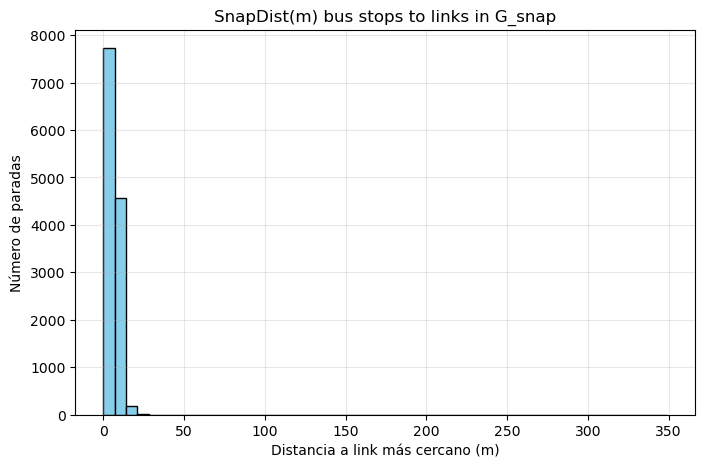

In [543]:
# Histograma de distancias de snap (en metros)
plt.figure(figsize=(8, 5))
plt.hist(bus_stops["SnapDist_m"], bins=50, color='skyblue', edgecolor='black',)
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("SnapDist(m) bus stops to links in G_snap")
plt.grid(True, alpha=0.3)
plt.show()

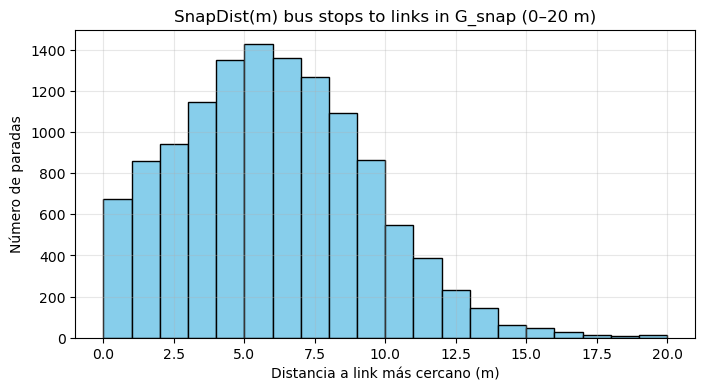

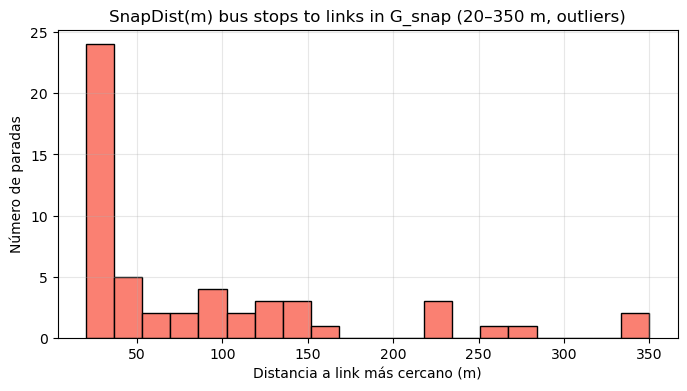

In [544]:
# Histograma para distancias pequeñas (0–20 m)
plt.figure(figsize=(8, 4))
plt.hist(bus_stops["SnapDist_m"], bins=20, color='skyblue', edgecolor='black', range=(0, 20))
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("SnapDist(m) bus stops to links in G_snap (0–20 m)")
plt.grid(True, alpha=0.3)
plt.show()

# Histograma para outliers (20–350 m)
plt.figure(figsize=(8, 4))
plt.hist(bus_stops["SnapDist_m"], bins=20, color='salmon', edgecolor='black', range=(20, 350))
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("SnapDist(m) bus stops to links in G_snap (20–350 m, outliers)")
plt.grid(True, alpha=0.3)
plt.show()

### Correct 28 stops (DANIEL) that should be in a service link + Jeannette's finds

In [545]:
#Bus stops DANIEL said should be snapped to a service link
bus_stops_service = gpd.read_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Insumos IMEPLAN\Transporte Publico\bus stops service DANIEL\puntos_que_si_son_service_agrupado.shp')

In [546]:
id_sp_service = bus_stops_service['id'].dropna().tolist()
id_sp_service += bus_stops_service['id_2'].dropna().tolist()
id_sp_service += bus_stops_service['id_3'].dropna().tolist()
id_sp_service += bus_stops_service['id_4'].dropna().tolist()

# Busqueda manual en outliers Jeannette
# stops with an original SNAP_DIST > 25 (de 25 hasta 350)
service_outliers = [11450, 12288, 7913, 4382, 8508, 12024, 12026, 4385, 1208, 4384, 12180, 4383, 12029, 10768, 11462, 6249]
living_street_outliers = [10349, 10872, 8211, 2322, 2033, 2323, 2197, 2031, 2345, 2028, 2034, 2346, 2359, 2361, 10737, 201, 10741, 2852]

id_sp_service += service_outliers
print('bus stops that SHOULD BE in a service link:', len(id_sp_service))
print('bus stops that SHOULD BE in a service link (unicos):', len(set(id_sp_service)))
print('bus stops that SHOULD BE in a living_street link:', len(living_street_outliers))

bus stops that SHOULD BE in a service link: 44
bus stops that SHOULD BE in a service link (unicos): 44
bus stops that SHOULD BE in a living_street link: 18


### Find stops for service/living_street in bus_stops DF

In [547]:
bus_stops_service = bus_stops[bus_stops['id'].isin(id_sp_service)].copy()
bus_stops_living_street = bus_stops[bus_stops['id'].isin(living_street_outliers)].copy()

### Snap bus stops identified to be in a service link

In [548]:
nearest_nodes = ox.nearest_nodes(G_snap_service, bus_stops_service["XCoord"], bus_stops_service["YCoord"])
nearest_edges, edge_distance = ox.nearest_edges(
    G_snap_service, # G_snap_service (solo links de service)
    X=bus_stops_service["XCoord"],
    Y=bus_stops_service["YCoord"],
    return_dist=True
)

bus_stops_service["NearestEdge"] = list(nearest_edges)
bus_stops_service["SnapDist_m"] = edge_distance

nearest_link_nos = []
rel_positions = []
from_node_nos = []
to_node_nos = []
nearest_highways = []

for row in bus_stops_service.itertuples():
    e = row.NearestEdge
    from_node = e[0]
    to_node = e[1]
    link_no = e[2]

    if e in gdf_links.index:
        record = gdf_links.loc[e]
        line = record.geometry
        p = row.geometry

        rel = 0.0
        try:
            if line.length > 0:
                rel = float(line.project(p) / line.length)
        except Exception:
            rel = 0.0

        nearest_highways.append(record.HighwayType)
    else:
        rel = 0.0
        nearest_highways.append(None)

    from_node_nos.append(from_node)
    to_node_nos.append(to_node)
    nearest_link_nos.append(link_no)
    rel_positions.append(rel)

bus_stops_service["FromNodeNo"] = from_node_nos
bus_stops_service["ToNodeNo"] = to_node_nos
bus_stops_service["LinkNo"] = nearest_link_nos
bus_stops_service["RelPosOnLink"] = rel_positions
bus_stops_service["NearestLink_HighwayVal"] = nearest_highways

In [549]:
bus_stops_service["NearestLink_HighwayVal"].value_counts()

NearestLink_HighwayVal
['service']    44
Name: count, dtype: int64

### Snap bus stops identified to be in a living street

In [550]:
nearest_nodes = ox.nearest_nodes(G_snap_livingST, bus_stops_living_street["XCoord"], bus_stops_living_street["YCoord"])
nearest_edges, edge_distance = ox.nearest_edges(
    G_snap_livingST, # G_snap_livingST (solo links de living street)
    X=bus_stops_living_street["XCoord"],
    Y=bus_stops_living_street["YCoord"],
    return_dist=True
)

bus_stops_living_street["NearestEdge"] = list(nearest_edges)
bus_stops_living_street["SnapDist_m"] = edge_distance

nearest_link_nos = []
rel_positions = []
from_node_nos = []
to_node_nos = []
nearest_highways = []

for row in bus_stops_living_street.itertuples():
    e = row.NearestEdge
    from_node = e[0]
    to_node = e[1]
    link_no = e[2]

    if e in gdf_links.index:
        record = gdf_links.loc[e]
        line = record.geometry
        p = row.geometry

        rel = 0.0
        try:
            if line.length > 0:
                rel = float(line.project(p) / line.length)
        except Exception:
            rel = 0.0

        nearest_highways.append(record.HighwayType)
    else:
        rel = 0.0
        nearest_highways.append(None)

    from_node_nos.append(from_node)
    to_node_nos.append(to_node)
    nearest_link_nos.append(link_no)
    rel_positions.append(rel)

bus_stops_living_street["FromNodeNo"] = from_node_nos
bus_stops_living_street["ToNodeNo"] = to_node_nos
bus_stops_living_street["LinkNo"] = nearest_link_nos
bus_stops_living_street["RelPosOnLink"] = rel_positions
bus_stops_living_street["NearestLink_HighwayVal"] = nearest_highways

In [551]:
#ERROR EN SP 2031 encontro bien el nearest link pero dijo el de fromnode to node que no era
bus_stops_living_street

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,geometry,XCoord,YCoord,NearestEdge,SnapDist_m,FromNodeNo,ToNodeNo,LinkNo,RelPosOnLink,NearestLink_HighwayVal
192,201.0,0.0,0.0,0.0,0.0,1.0,0.0,C35,N/A,N/A,...,POINT (691789.87 2279876.968),691789.869992,2.279877e+06,"(27900.0, 14968.0, 72263.0)",4.057484,27900.0,14968.0,72263.0,0.647497,['living_street']
2011,2028.0,0.0,0.0,0.0,0.0,0.0,0.0,T16B-C03,N/A,N/A,...,POINT (658953.157 2298197.072),658953.157231,2.298197e+06,"(194904.0, 186653.0, 450750.0)",5.459538,194904.0,186653.0,450750.0,0.022272,['living_street']
2014,2031.0,0.0,0.0,0.0,0.0,0.0,0.0,T16B-C03,N/A,N/A,...,POINT (658949.003 2298052.333),658949.003330,2.298052e+06,"(175570.0, 171992.0, 418877.0)",1.903000,175570.0,171992.0,418877.0,0.873628,['living_street']
2016,2033.0,0.0,0.0,0.0,0.0,0.0,0.0,T16B-C03,N/A,N/A,...,POINT (658957.096 2298031.286),658957.096214,2.298031e+06,"(171992.0, 172000.0, 418878.0)",7.323192,171992.0,172000.0,418878.0,0.071466,['living_street']
2017,2034.0,0.0,0.0,0.0,0.0,0.0,0.0,T16B-C03,N/A,N/A,...,POINT (658960.835 2298176.983),658960.835399,2.298177e+06,"(175570.0, 186653.0, 427348.0)",2.028317,175570.0,186653.0,427348.0,0.859431,['living_street']
2179,2197.0,0.0,0.0,0.0,0.0,0.0,0.0,C106,N/A,N/A,...,POINT (690655.194 2279305.994),690655.193751,2.279306e+06,"(1003.0, 205.0, 567.0)",7.686592,1003.0,205.0,567.0,0.768732,['living_street']
2304,2322.0,0.0,0.0,0.0,0.0,0.0,0.0,C35,N/A,N/A,...,POINT (691805.371 2279980.106),691805.371449,2.279980e+06,"(15069.0, 27903.0, 41353.0)",5.873967,15069.0,27903.0,41353.0,0.822631,['living_street']
2305,2323.0,0.0,0.0,0.0,0.0,0.0,0.0,C35,N/A,N/A,...,POINT (691808.446 2280042.638),691808.446123,2.280043e+06,"(26684.0, 27899.0, 69514.0)",2.717538,26684.0,27899.0,69514.0,0.832790,['living_street']
2327,2345.0,0.0,0.0,0.0,0.0,0.0,0.0,C35,N/A,N/A,...,POINT (691773.387 2280167.701),691773.386852,2.280168e+06,"(14996.0, 26651.0, 41188.0)",3.595728,14996.0,26651.0,41188.0,0.884560,['living_street']
2328,2346.0,0.0,0.0,0.0,0.0,0.0,0.0,C35,N/A,N/A,...,POINT (691733.775 2280191.18),691733.775467,2.280191e+06,"(26654.0, 26650.0, 69448.0)",1.058472,26654.0,26650.0,69448.0,0.559265,['living_street']


### Update in bus stops the corrections for: 44 service & 18 living street

In [552]:
cols_to_update = ["NearestEdge", "SnapDist_m", "FromNodeNo", "ToNodeNo", "LinkNo", "RelPosOnLink", "NearestLink_HighwayVal"]
bus_stops.set_index("id", inplace=True)
bus_stops_service.set_index("id", inplace=True)
bus_stops_living_street.set_index("id", inplace=True)

bus_stops.update(bus_stops_service[cols_to_update])
bus_stops.update(bus_stops_living_street[cols_to_update])
bus_stops.reset_index(inplace=True)
bus_stops['stop_id'] = range(1, len(bus_stops) + 1)

In [553]:
# Should now have 42 service stops and 18 living street stops
bus_stops['NearestLink_HighwayVal'].value_counts()

NearestLink_HighwayVal
['residential']                     5104
['tertiary']                        3731
['secondary']                       1711
['primary']                         1312
['trunk']                            230
['unclassified']                     225
['service']                           44
['trunk_link']                        43
['primary_link']                      41
['living_street']                     18
['motorway_link']                     16
['tertiary_link']                     13
['secondary_link']                    12
['motorway']                          11
['tertiary', 'secondary']              2
['secondary_link', 'secondary']        2
['motorway_link', 'residential']       1
['trunk_link', 'residential']          1
['tertiary', 'trunk_link']             1
Name: count, dtype: int64

### Histogram of Snap Distance with corrected SP & outliers

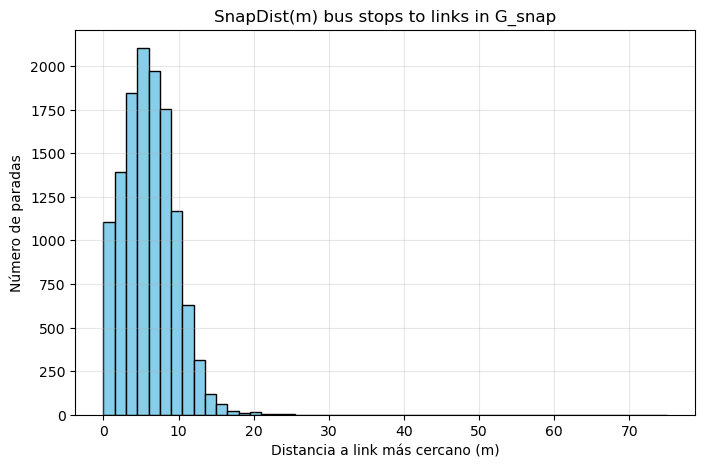

In [554]:
# Histograma de distancias de snap (en metros)
plt.figure(figsize=(8, 5))
plt.hist(bus_stops["SnapDist_m"], bins=50, color='skyblue', edgecolor='black',)
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("SnapDist(m) bus stops to links in G_snap")
plt.grid(True, alpha=0.3)
plt.show()

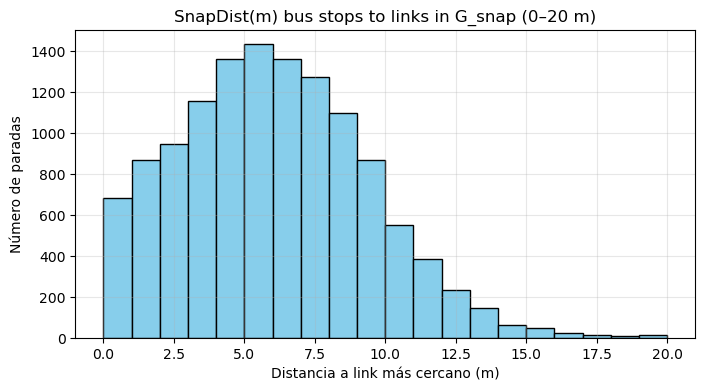

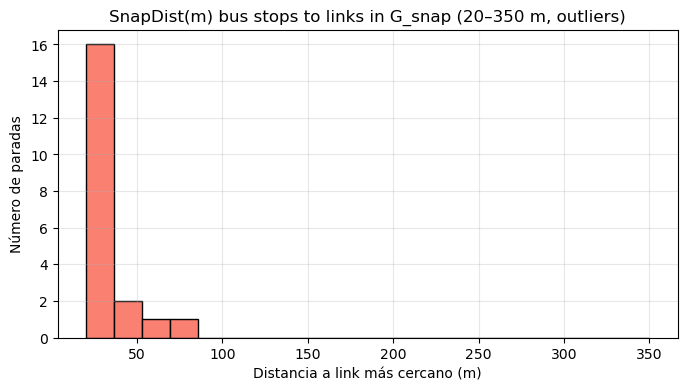

In [555]:
# Histograma para distancias pequeñas (0–20 m)
plt.figure(figsize=(8, 4))
plt.hist(bus_stops["SnapDist_m"], bins=20, color='skyblue', edgecolor='black', range=(0, 20))
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("SnapDist(m) bus stops to links in G_snap (0–20 m)")
plt.grid(True, alpha=0.3)
plt.show()

# Histograma para outliers (20–350 m)
plt.figure(figsize=(8, 4))
plt.hist(bus_stops["SnapDist_m"], bins=20, color='salmon', edgecolor='black', range=(20, 350))
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("SnapDist(m) bus stops to links in G_snap (20–350 m, outliers)")
plt.grid(True, alpha=0.3)
plt.show()

## __Leave only 1 SP per Link__

In [565]:
bus_stops_1perlink = bus_stops.copy()
route_cols = [f"ruta_{i}" for i in range(1, 36)]

bus_stops_grouped = (
    bus_stops.groupby('LinkNo')
    .agg({
        "SnapDist_m" : "first",
        "FromNodeNo": "first",
        "ToNodeNo": "first",
        #"LinkNo": "first",
        "RelPosOnLink": "first",
        "NearestLink_HighwayVal":"first",
    })
)
bus_stops_grouped

,SnapDist_m,FromNodeNo,ToNodeNo,RelPosOnLink,NearestLink_HighwayVal
LinkNo,,,,,
17.0,4.376964,9.0,19477.0,0.890794,['primary']
29.0,5.370930,14.0,25112.0,0.699219,['secondary']
31.0,7.816146,30532.0,15.0,0.812254,['secondary']
34.0,8.525980,17478.0,15.0,0.971437,['residential']
43.0,5.111749,19.0,21303.0,0.773907,['secondary']
...,...,...,...,...,...
496646.0,2.088312,209176.0,83364.0,0.909114,['residential']
496975.0,0.431684,209505.0,94404.0,0.779113,['residential']
497289.0,7.369992,209819.0,105954.0,0.158390,['service']


In [568]:
route_cols = [f"ruta_{i}" for i in range(1, 36)]


df_routes = (
    bus_stops.groupby('LinkNo')[route_cols]
    .apply(lambda g: ",".join(
        sorted({r for r in g.values.flatten() if pd.notnull(r)})
    ))
    .reset_index(name="route_list")
)
df_routes[df_routes['LinkNo']==17]

,LinkNo,route_list
0,17.0,"ATQ-IXT,Caj-SJuan,IXT-ATQ,IXT-Macro,IXT-Tren,N..."


In [572]:
bus_stops_unified = bus_stops_grouped.merge(df_routes, on='LinkNo')
bus_stops_unified['SP_id'] = range(1, len(bus_stops_unified) + 1)
bus_stops_unified

,LinkNo,SnapDist_m,FromNodeNo,ToNodeNo,RelPosOnLink,NearestLink_HighwayVal,route_list,SP_id
0,17.0,4.376964,9.0,19477.0,0.890794,['primary'],"ATQ-IXT,Caj-SJuan,IXT-ATQ,IXT-Macro,IXT-Tren,N...",1
1,29.0,5.370930,14.0,25112.0,0.699219,['secondary'],"N/A,T13C-C01,T13C-C02,T13C-C03,T13C-C04,Tronca...",2
2,31.0,7.816146,30532.0,15.0,0.812254,['secondary'],"N/A,T13C-C02,T13C-C03,T13C-C04,Troncal 13C Sol...",3
3,34.0,8.525980,17478.0,15.0,0.971437,['residential'],"N/A,T13C-C02,T13C-C03,T13C-C04,Troncal 13C Sol...",4
4,43.0,5.111749,19.0,21303.0,0.773907,['secondary'],"N/A,T13C-C02,T13C-C03,T13C-C04,Troncal 13C Sol...",5
...,...,...,...,...,...,...,...,...
11395,496646.0,2.088312,209176.0,83364.0,0.909114,['residential'],"C125-V1,C125-V2,N/A",11396
11396,496975.0,0.431684,209505.0,94404.0,0.779113,['residential'],"C09,C127,N/A",11397
11397,497289.0,7.369992,209819.0,105954.0,0.158390,['service'],"C66,N/A,Troncal 11 Río Nilo Guadalupe",11398
11398,499039.0,2.409490,211569.0,187034.0,0.445711,['residential'],"C73,N/A",11399


### Adjust Relative position >0.1 AND <0.9

In [575]:
bus_stops_unified['RelPosOnLink'] = bus_stops_unified['RelPosOnLink'].clip(0.1, 0.9)

In [578]:
bus_stops_unified

,LinkNo,SnapDist_m,FromNodeNo,ToNodeNo,RelPosOnLink,NearestLink_HighwayVal,route_list,SP_id
0,17.0,4.376964,9.0,19477.0,0.890794,['primary'],"ATQ-IXT,Caj-SJuan,IXT-ATQ,IXT-Macro,IXT-Tren,N...",1
1,29.0,5.370930,14.0,25112.0,0.699219,['secondary'],"N/A,T13C-C01,T13C-C02,T13C-C03,T13C-C04,Tronca...",2
2,31.0,7.816146,30532.0,15.0,0.812254,['secondary'],"N/A,T13C-C02,T13C-C03,T13C-C04,Troncal 13C Sol...",3
3,34.0,8.525980,17478.0,15.0,0.900000,['residential'],"N/A,T13C-C02,T13C-C03,T13C-C04,Troncal 13C Sol...",4
4,43.0,5.111749,19.0,21303.0,0.773907,['secondary'],"N/A,T13C-C02,T13C-C03,T13C-C04,Troncal 13C Sol...",5
...,...,...,...,...,...,...,...,...
11395,496646.0,2.088312,209176.0,83364.0,0.900000,['residential'],"C125-V1,C125-V2,N/A",11396
11396,496975.0,0.431684,209505.0,94404.0,0.779113,['residential'],"C09,C127,N/A",11397
11397,497289.0,7.369992,209819.0,105954.0,0.158390,['service'],"C66,N/A,Troncal 11 Río Nilo Guadalupe",11398
11398,499039.0,2.409490,211569.0,187034.0,0.445711,['residential'],"C73,N/A",11399


In [586]:
stops = bus_stops[['id', 'stop_id', 'XCoord', 'YCoord', 'geometry', 'LinkNo']].copy()
bus_stops_processed = stops.merge(bus_stops_unified, on='LinkNo', how='inner')

In [587]:
bus_stops_processed[bus_stops_processed['LinkNo']==17]

,id,stop_id,XCoord,YCoord,geometry,LinkNo,SnapDist_m,FromNodeNo,ToNodeNo,RelPosOnLink,NearestLink_HighwayVal,route_list,SP_id
5852,5944.0,5853,682351.393873,2.262784e+06,POINT (682351.394 2262784.143),17.0,4.376964,9.0,19477.0,0.890794,['primary'],"ATQ-IXT,Caj-SJuan,IXT-ATQ,IXT-Macro,IXT-Tren,N...",1
5854,5946.0,5855,682408.249491,2.262868e+06,POINT (682408.249 2262867.758),17.0,4.376964,9.0,19477.0,0.890794,['primary'],"ATQ-IXT,Caj-SJuan,IXT-ATQ,IXT-Macro,IXT-Tren,N...",1


In [588]:
bus_stops_processed.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Objects\Bus Stops Snapped to Visum Link\bus_stops_snapped.shp')

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_19160\2920292552.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  bus_stops_processed.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Objects\Bus Stops Snapped to Visum Link\bus_stops_snapped.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'RelPosOnLink' to 'RelPosOnLi'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NearestLink_HighwayVal' to 'NearestLin'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 'ATQ-IXT,Agaves-CV,C102,C111-V1,C111-V3,C112,C41-V1,C41-V2,C47-V2,C48,C67,C67-V2,C80-V3,C83,C97-V2,Caj-SJuan,IXT-ATQ,IXT-Macro,N

## __**DON'T USE ANYMORE**__ (more than 1 sp per link)

## __Set Adjusted Relative Position__

In [556]:
# Define limits, forbidden middle zone, and minimum gap
MIN_REL_POS = 0.1
MAX_REL_POS = 0.9
FORBIDDEN_LOW = 0.45
FORBIDDEN_HIGH = 0.55
MIN_GAP = 0.002

# Define valid ranges for snapping
left_range = (MIN_REL_POS, FORBIDDEN_LOW - MIN_GAP)
right_range = (FORBIDDEN_HIGH + MIN_GAP, MAX_REL_POS)
left_size = left_range[1] - left_range[0]
right_size = right_range[1] - right_range[0]

print(f"Left range: {left_range}, size: {left_size}")
print(f"Right range: {right_range}, size: {right_size}")

Left range: (0.1, 0.448), size: 0.348
Right range: (0.552, 0.9), size: 0.348


In [557]:
def adjust_group(group):
    group = group.sort_values('RelPosOnLink').copy()
    n = len(group)

    #if only one stop per link
    if n == 1:
        #set to 0.1 if lower, set to 0.9 if higher
        position = np.clip(group['RelPosOnLink'].values, MIN_REL_POS, MAX_REL_POS)

        #avoid forbidden zone 0.45-0.55
        if FORBIDDEN_LOW < position[0] < FORBIDDEN_HIGH:
            if position[0] < 0.5:
                position[0] = FORBIDDEN_LOW - MIN_GAP
            else:
                position[0] = FORBIDDEN_HIGH + MIN_GAP
        
        group['RelPos_New'] = position
        return group
    
    # if multiple stops per link
    left_range = (MIN_REL_POS, FORBIDDEN_LOW - MIN_GAP)
    right_range = (FORBIDDEN_HIGH + MIN_GAP, MAX_REL_POS)
    left_size = left_range[1] - left_range[0]
    right_size = right_range[1] - right_range[0]
    total_size = left_size + right_size

    # asignar proporcionalmente a cada lado
    n_left = int(np.round(n * (left_size / total_size)))
    n_right = n - n_left

    if n_left == 0:
        n_left = 1
        n_right = n - 1
    elif n_right == 0:
        n_right = 1
        n_left = n - 1

    # generar posiciones para cada lado
    left_positions = np.linspace(left_range[0], left_range[1], n_left)
    right_positions = np.linspace(right_range[0], right_range[1], n_right)
    new_positions = np.concatenate([left_positions, right_positions])

    group = group.sort_values('RelPosOnLink')
    group['RelPos_New'] = new_positions

    # asegurar gap mínimo
    pos = group['RelPos_New'].values
    for i in range(1, len(pos)):
        if pos[i] - pos[i-1] < MIN_GAP:
            pos[i] = pos[i-1] + MIN_GAP
    
    pos = np.clip(pos, MIN_REL_POS, MAX_REL_POS)
    group['RelPos_New'] = pos
    
    return group

In [558]:
bus_stops_processed = bus_stops.copy()
bus_stops_processed = (
    bus_stops_processed
    .groupby("LinkNo", group_keys=False)
    .apply(adjust_group)
)

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_19160\3935052058.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(adjust_group)


In [559]:
bus_stops_processed[bus_stops_processed['id'] == 11462]

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,YCoord,NearestEdge,SnapDist_m,FromNodeNo,ToNodeNo,LinkNo,RelPosOnLink,NearestLink_HighwayVal,stop_id,RelPos_New
11281,11462.0,0.0,1.0,1.0,0.0,1.0,0.0,Troncal 08 Americas,N/A,N/A,...,2.294661e+06,"(156335.0, 156336.0, 381283.0)",12.762254,156335.0,156336.0,381283.0,0.59437,['service'],11282,0.59437


In [560]:
bus_stops_processed.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Objects\Bus Stops Snapped to Visum Link\bus_stops_snapped.shp')

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_19160\2920292552.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  bus_stops_processed.to_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Objects\Bus Stops Snapped to Visum Link\bus_stops_snapped.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NearestEdge' to 'NearestEdg'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'RelPosOnLink' to 'RelPosOnLi'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NearestLink_HighwayVal' to 'NearestLin'
  ogr_write(
